# Modeling Progress Summary

## Overview
This document is a technical summary of the modeling workflow for the remote-sensing backup generator project. It explains:

- what we modeled
- why each modeling upgrade was introduced
- what each model is responsible for
- how the results changed across stages
- what the current bottlenecks are
- what we expect to do next

The active modeling entry points are:

- `project/modeling/pipelines/01_in_sample_pipeline.py`
- `project/modeling/pipelines/02_cross_event_pipeline.py`
- `project/modeling/pipelines/03_exploration_pipeline.py`

The project now has two distinct goals:

1. **Explanatory modeling**
   We want to know whether pixels inside critical-infrastructure buffers are systematically more resilient than comparable pixels outside the buffer.

2. **Cross-event transport**
   We want to know whether the model can generalize to an unseen event, not just fit the events already in the training set.

That split matters, because the same model family does not perform equally well on both tasks.

## Data and Sample Design

### Core pixel schema
The main pixel-level table is built around:

- `pixel_id`
- `event_id`
- `lon`, `lat`
- `pre_mean_ntl`
- `post_mean_ntl`
- `delta_ntl`
- `in_buffer`
- `distance_to_nearest`
- `n_facilities_in_buffer`
- `facility_type_std`
- `is_damaged`

Later stages add:

- `land_use_group`
- OSM local context features
- cloud / observation-quality features
- local land-use shares
- event profile features
- repaired population-density covariates for international stages

### Sample locking
One important engineering change was the introduction of a locked cohort. We explicitly stopped allowing different model variants to silently use different samples.

Why this mattered:

- earlier comparisons could be contaminated by sample drift
- land-use or cloud features could indirectly redefine the estimation sample
- we wanted “with feature” vs “without feature” to mean the same pixels unless a stage explicitly changed the event set

This change is one reason later comparisons are more trustworthy than the earlier ones.

## Modeling Timeline

## Stage 1: Baseline 6-event models

### Why we started here
The first goal was to establish a reproducible baseline using a limited but coherent set of six events. At this stage, the main question was simply whether the buffer signal existed at all.

### What we used

- pixel-level nightlight change
- buffer membership
- facility distance / local facility count
- event controls

### Main models

- `OLS`
- `MixedLM`
- `Logit`
- `Cox`

### Main result
The buffer signal appeared early and was directionally consistent:

- buffer pixels were generally more resilient than non-buffer pixels
- `MixedLM` was the strongest explanatory model
- the first transport baseline was still workable

Key baseline transport metrics:

- `hazard-mainline Logit AUC = 0.6001`
- `survival best = 0.5341`

At this point, the project looked promising, but the event set was still narrow enough that generalization had not been stress-tested.

## Stage 2: Land-use and feature upgrades

### Why we changed the model
The baseline still risked confounding buffer effects with urban form and land-use composition. A buffer located in dense developed land is not directly comparable to a pixel in water, wetlands, or rural edge land.

So we introduced:

- NLCD-based land-use controls
- grouped land-use categories
- OSM local infrastructure features
- cloud-validity proxies
- sample locking

### What this fixed
This stage directly targeted three known problems:

1. **Land-use confounding**
2. **Infrastructure-context omission**
3. **Sample inconsistency across model variants**

### Result
This stage produced a much cleaner specification family, which later became `strict-v2`. It did not solve cross-event transport, but it improved interpretability and made the explanatory models more defensible.

Reference figure:

<img src="project/modeling_report/figures/feature_upgrade/feature_upgrade_model_compare_locked.png" width="900">

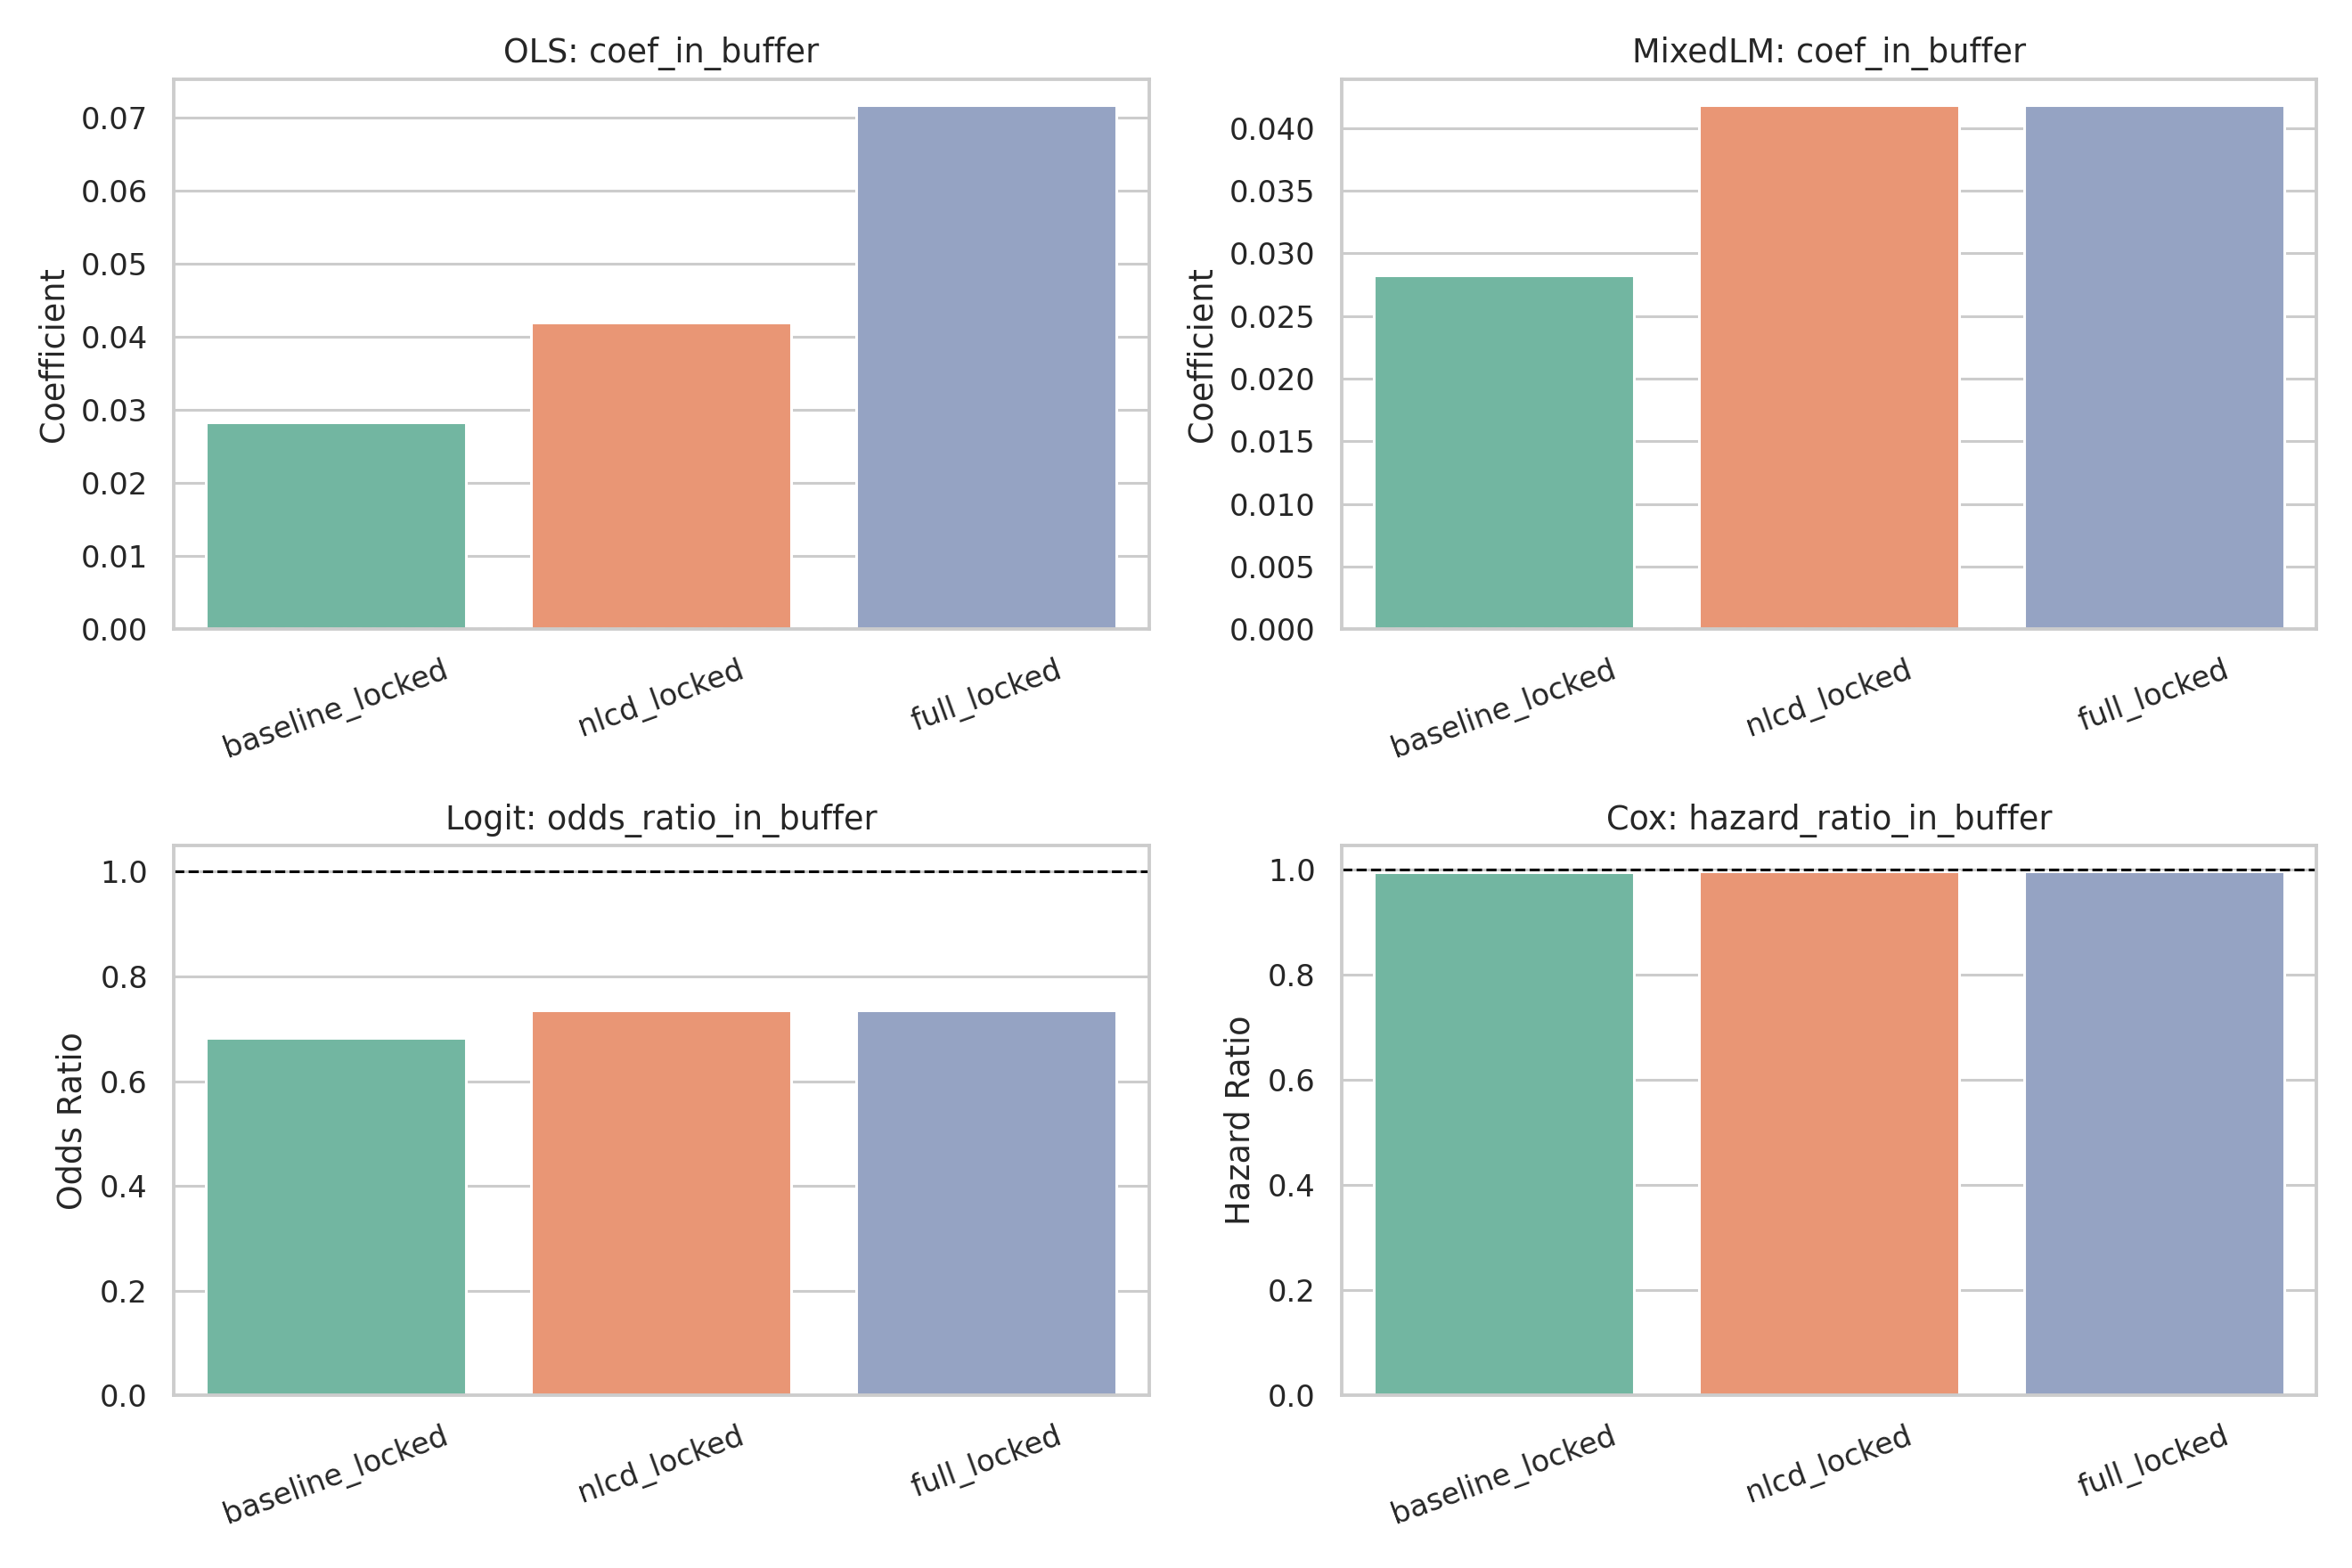

In [ ]:
# Embedded figure: feature_upgrade_model_compare_locked.png


## Stage 3: Strict-v2

### Why we created strict-v2
By this point the project had accumulated enough features that identifiability started to matter more than raw feature count. We therefore created a stricter version of the pipeline with:

- cleaner feature inclusion rules
- a tighter cloud proxy design
- exclusion of audit-only variables from the main formula
- VIF gating
- fail-fast behavior when a specification became unstable

### What strict-v2 is trying to do
`strict-v2` is not the most ambitious model. It is the cleanest explanatory model. Its role is to answer:

> holding the main controls fixed, does the buffer signal remain stable?

### Current reading
In the 6-event setup, `strict-v2` remained the strongest explanatory line.

Representative values from the locked full specification:

- `OLS coef(in_buffer) = 0.0254`, `p = 0.0975`
- `MixedLM coef(in_buffer) = 0.0254`, `p = 0.0149`
- `Logit OR(in_buffer) = 0.7823`
- `strict-v2 Logit AUC = 0.7302`
- `Cox HR(in_buffer) = 1.3274`

The main takeaway is that the buffer effect remains directionally stable under a stricter specification.

## Stage 4: Cross-event transport modeling

### Why we built a separate transport line
The explanatory models were answering an important question, but not the hardest one. We also wanted to know:

> if one event is held out entirely, can the model still predict relative damage or recovery behavior?

This required a different modeling logic:

- event-profile features
- local land-use-share features
- explicit LOEO evaluation
- benchmark models for comparison

### Why transport is harder
In-sample explanation and cross-event transport are not the same problem.

- Explanatory models can use event structure to stabilize estimates.
- Transport models must survive event-to-event domain shift.

That difference became central later.

Reference figure:

<img src="project/modeling_report/figures/cross_event/transport_metrics_compare_v3.png" width="900">

## Stage 5: Event expansion from 6 to 10 events

### Why we expanded the event set
The six-event configuration was still too narrow. We believed some of the transport weakness might come from missing event types, so we added:

- `ian_fortmyers`
- `ian_charlotteharbor`
- `earthquake_hatay`
- `dorian_freeport`

This was intended to cover missing structural gaps:

- additional coastal hurricanes
- a non-San-Juan earthquake
- a non-Puerto-Rico island-like hurricane

### What happened
The event set became more representative, but predictive transport became worse.

`hazard-mainline Logit AUC` changed as follows:

- 6-event baseline: `0.6001`
- Stage 7: `0.4914`
- Stage 8: `0.4856`
- Stage 9: `0.4726`
- Stage 10: `0.4762`

`survival best` changed as follows:

- baseline: `0.5341`
- Stage 7: `0.5312`
- Stage 8: `0.5125`
- Stage 9: `0.5219`
- Stage 10: `0.5161`

### Why this happened
This was not a random failure. It revealed a real modeling limit.

Direct event expansion increased:

- country heterogeneity
- island vs non-island heterogeneity
- hurricane vs earthquake heterogeneity
- urban-form variation
- observation-quality variation

The original transport specification could not absorb that much structure.

Reference figures:

<img src="project/modeling_report/figures/event_increment/logit_auc_by_stage.png" width="900">

<img src="project/modeling_report/figures/event_increment/survival_best_by_stage.png" width="900">

<img src="project/modeling_report/figures/event_increment/event_gap_coverage_map.png" width="900">

## Stage 6: International covariate repair and HZ2

### Why we isolated Stage 9 and Stage 10
The new international events exposed a separate problem: the international population-density covariate was not just weak, it was wrong.

For `earthquake_hatay` and `dorian_freeport`, the earlier field behaved like:

- a constant pseudo-value
- while still being flagged as missing

That meant the transport line was partly learning from a broken input.

### What we changed
We created a separate experimental line and repaired the international population-density covariate by:

- downloading `WorldPop 2020`
- sampling raster values directly at pixel coordinates
- writing new `*_v2` population fields
- building a leaner transport specification (`HZ2`)

### Why HZ2 is different
The earlier `HZ1` line included more event-level proxy structure. `HZ2` intentionally became slimmer and more local:

Numeric terms:

- `in_buffer`
- `pre_mean_ntl`
- `pixel_cloud_proxy`
- `recovery_obs_quality_score`
- `urban_share_1km`
- `water_share_1km`
- `developed_high_share_1km`
- `pop_density_log1p_v2`

Categorical terms:

- `land_use_group`
- `event_disaster_type`

Interactions:

- `in_buffer * pre_mean_ntl`
- `in_buffer * pop_density_log1p_v2`

### Result
The repair helped damage ranking, but not recovery transport.

Stage 9:

- Logit AUC: `0.4726 -> 0.5048`
- survival best: `0.5219 -> 0.4995`

Stage 10:

- Logit AUC: `0.4762 -> 0.4994`
- survival best: `0.5161 -> 0.5000`

Interpretation:

- the international population fix mattered
- the damage-classification line partially recovered
- the survival problem remained unresolved

That means the remaining bottleneck is not only covariate quality. Recovery is still being driven by:

- shallow post-event coverage
- censoring structure
- event-specific recovery dynamics

Reference figure:

<img src="project/modeling_report/figures/intl_stage_repair_v1/stage9_10_hz1_vs_hz2.png" width="900">

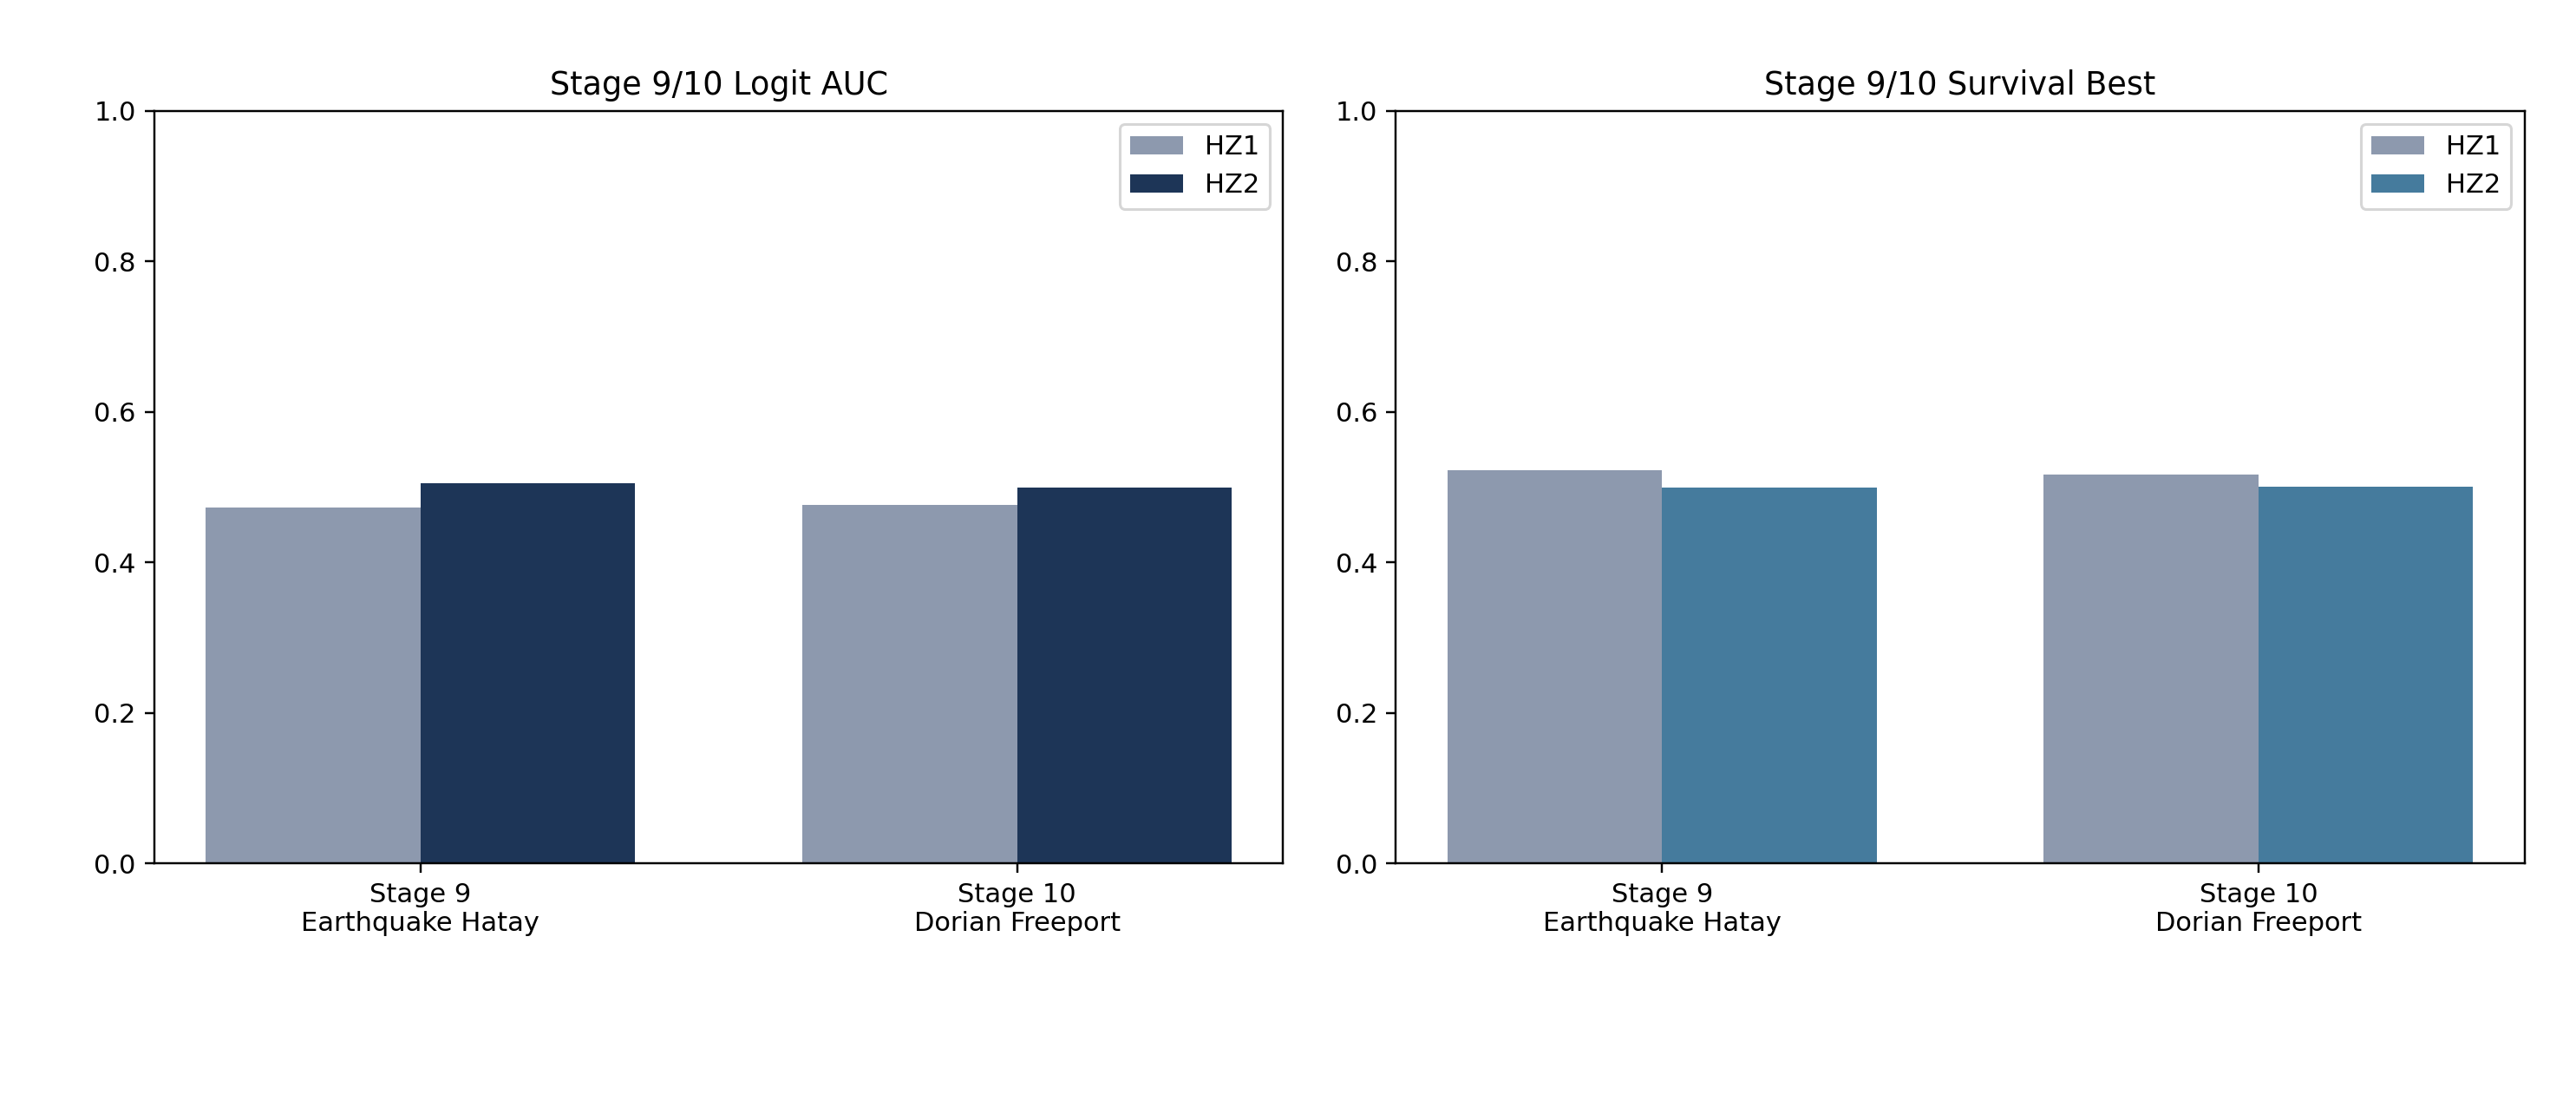

In [ ]:
# Embedded figure: stage9_10_hz1_vs_hz2.png


## Model-by-Model Summary

## OLS

### Purpose
Estimate average continuous change in nightlight intensity.

### Why we keep it
OLS is not the strongest final model, but it is still useful because it provides:

- a transparent baseline
- easily interpretable coefficient signs
- a quick check for directional stability

### Current reading
OLS improved in some intermediate stages, then weakened when the most heterogeneous events were added. It remains informative, but it is not the model we should rely on most heavily for final interpretation.

Reference figure:

<img src="project/modeling_report/figures/ols/ols_coefficients.png" width="820">

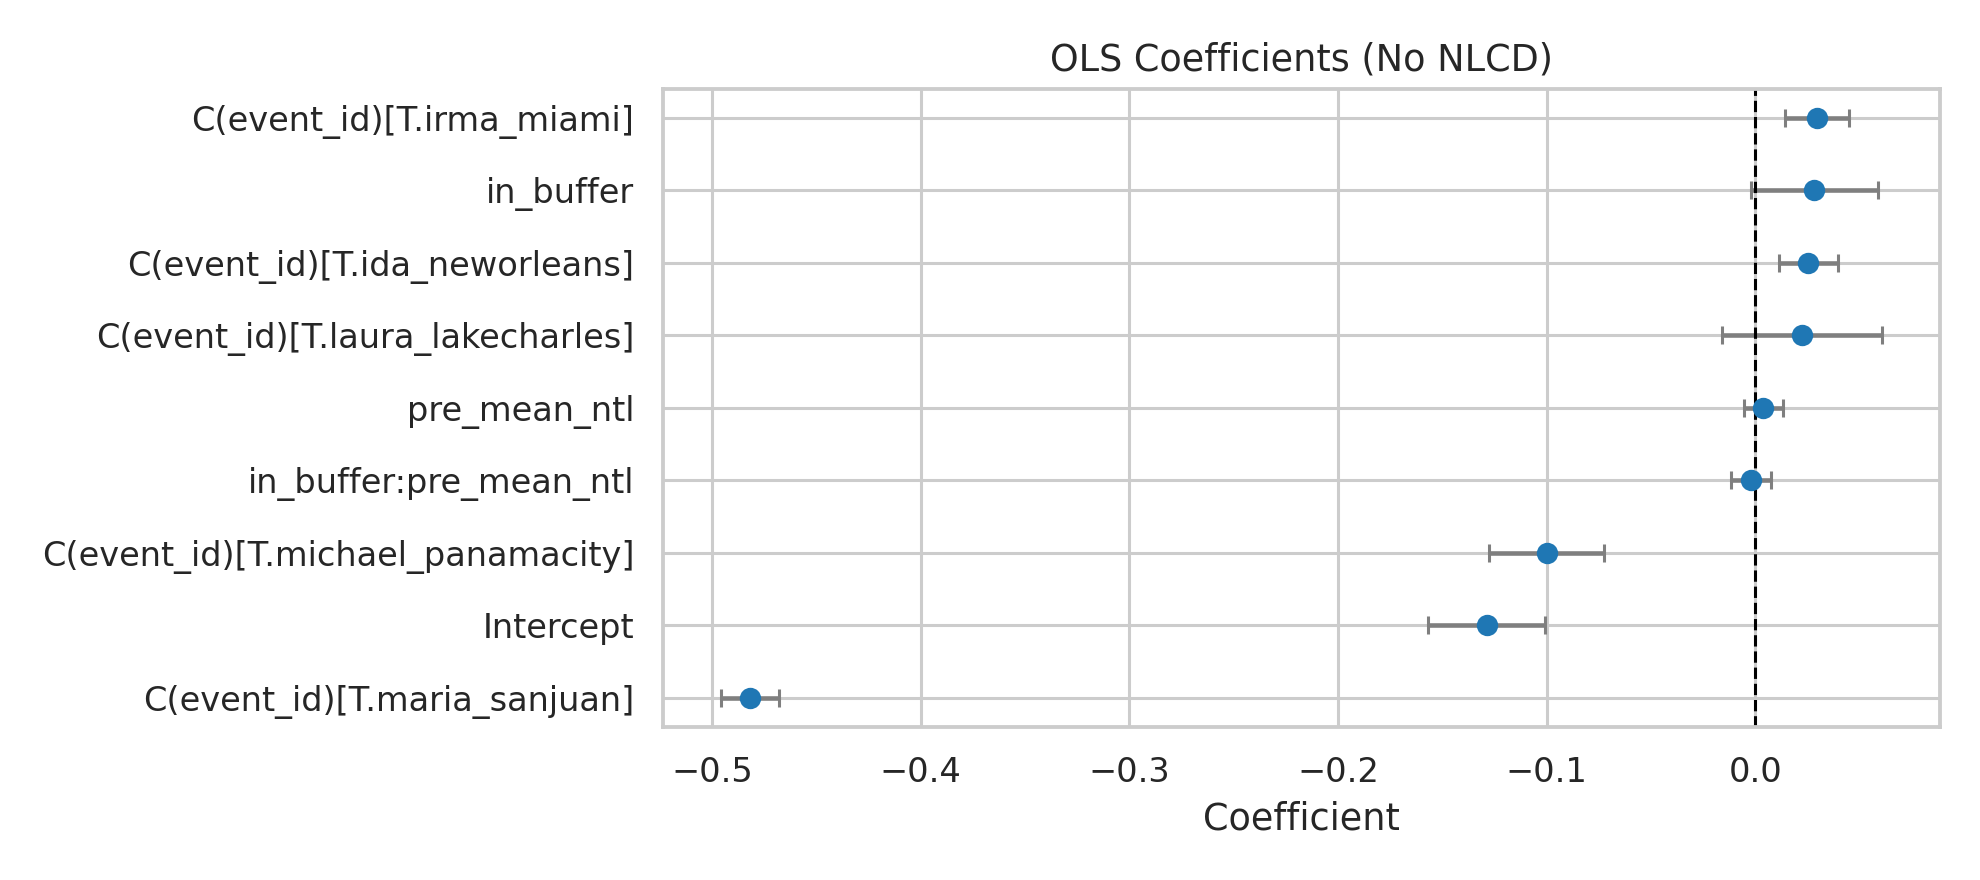

In [ ]:
# Embedded figure: ols_coefficients.png


## MixedLM

### Purpose
Estimate explanatory effects while allowing event-level random variation.

### Why it matters
This model is the best answer to the core explanatory question. It is specifically useful when:

- event-to-event baselines differ
- we want a stable fixed effect for `in_buffer`
- we do not want one event to dominate the interpretation

### Current reading
MixedLM is still the strongest explanatory model in the project. Even after event expansion, it stayed relatively stable and kept the buffer signal in the expected direction.

Reference figure:

<img src="project/modeling_report/figures/mixedlm/mixedlm_fixed_effects.png" width="820">

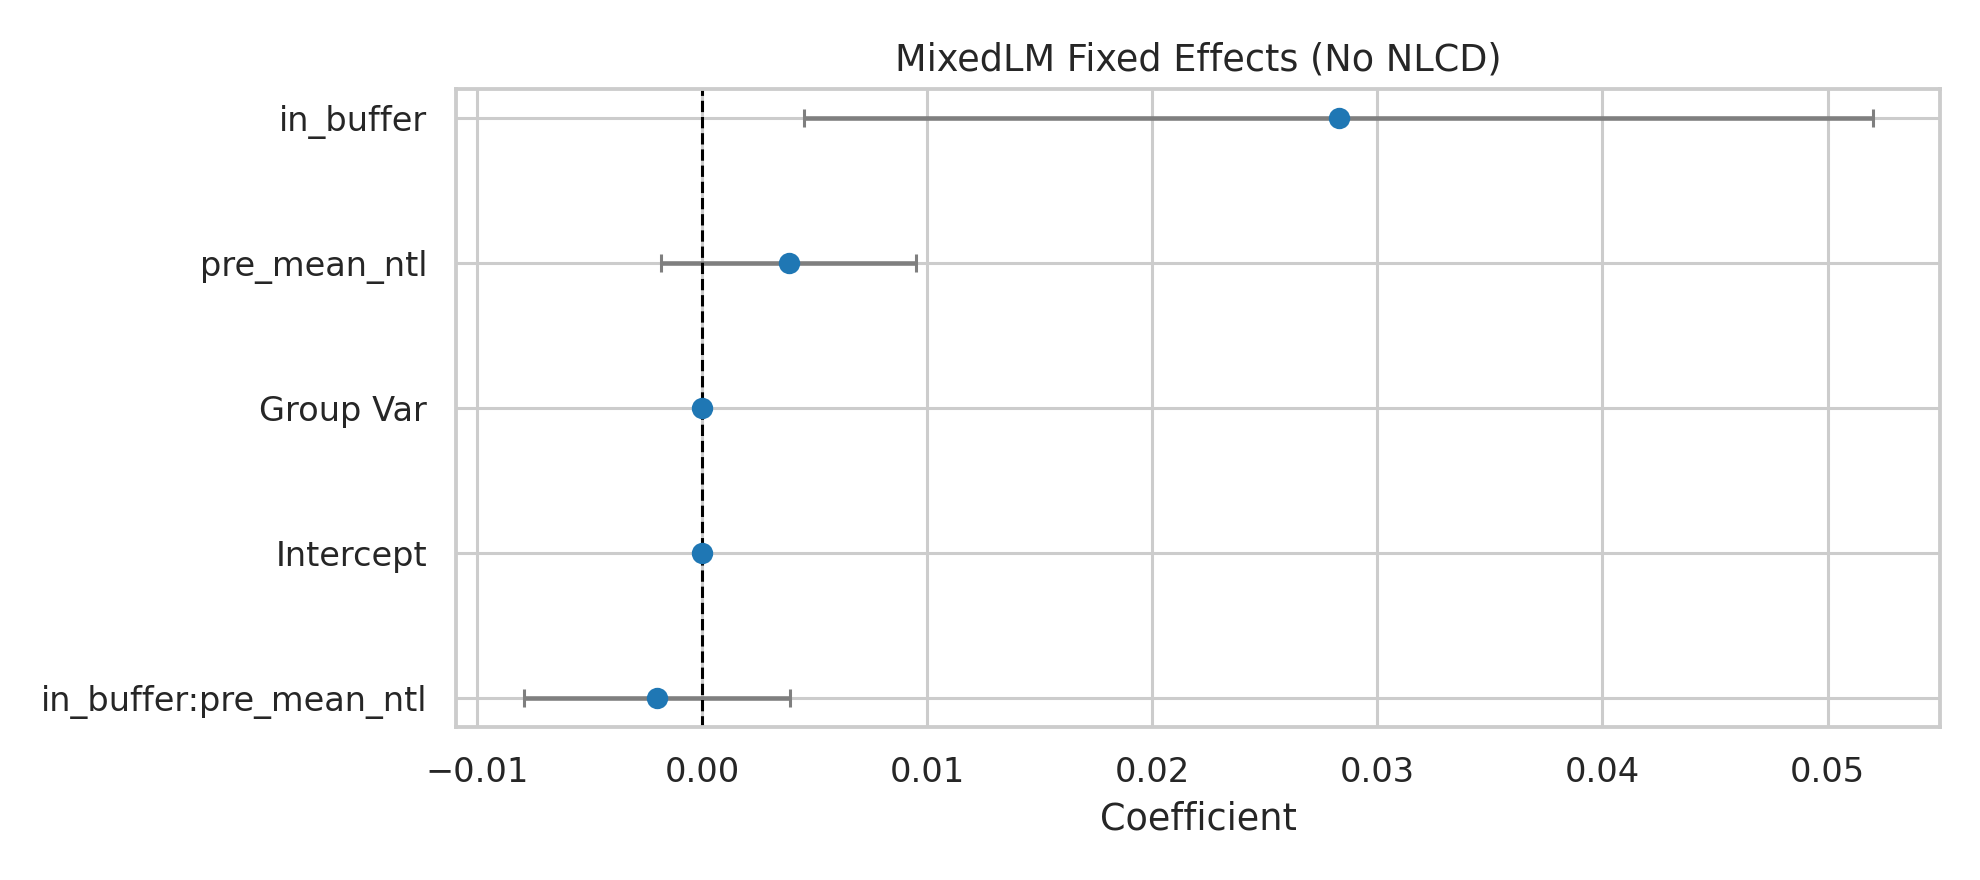

In [ ]:
# Embedded figure: mixedlm_fixed_effects.png


## Logit

### Purpose
Predict and explain damage probability.

### Why it became central
Once we moved into transport evaluation, Logit became the most informative model for damage ranking. It is also the clearest place to see the effect of event expansion.

### Current reading
Logit performed very well in the 6-event setting, deteriorated sharply after direct event expansion, and partially recovered after the international repair plus HZ2 redesign.

So Logit currently tells the clearest story about the project:

- the model can rank damage under a narrower event regime
- it struggles under higher event heterogeneity
- repairing broken covariates helps, but not enough by itself

Reference figure:

<img src="project/modeling_report/figures/logit/logit_roc_curve.png" width="820">

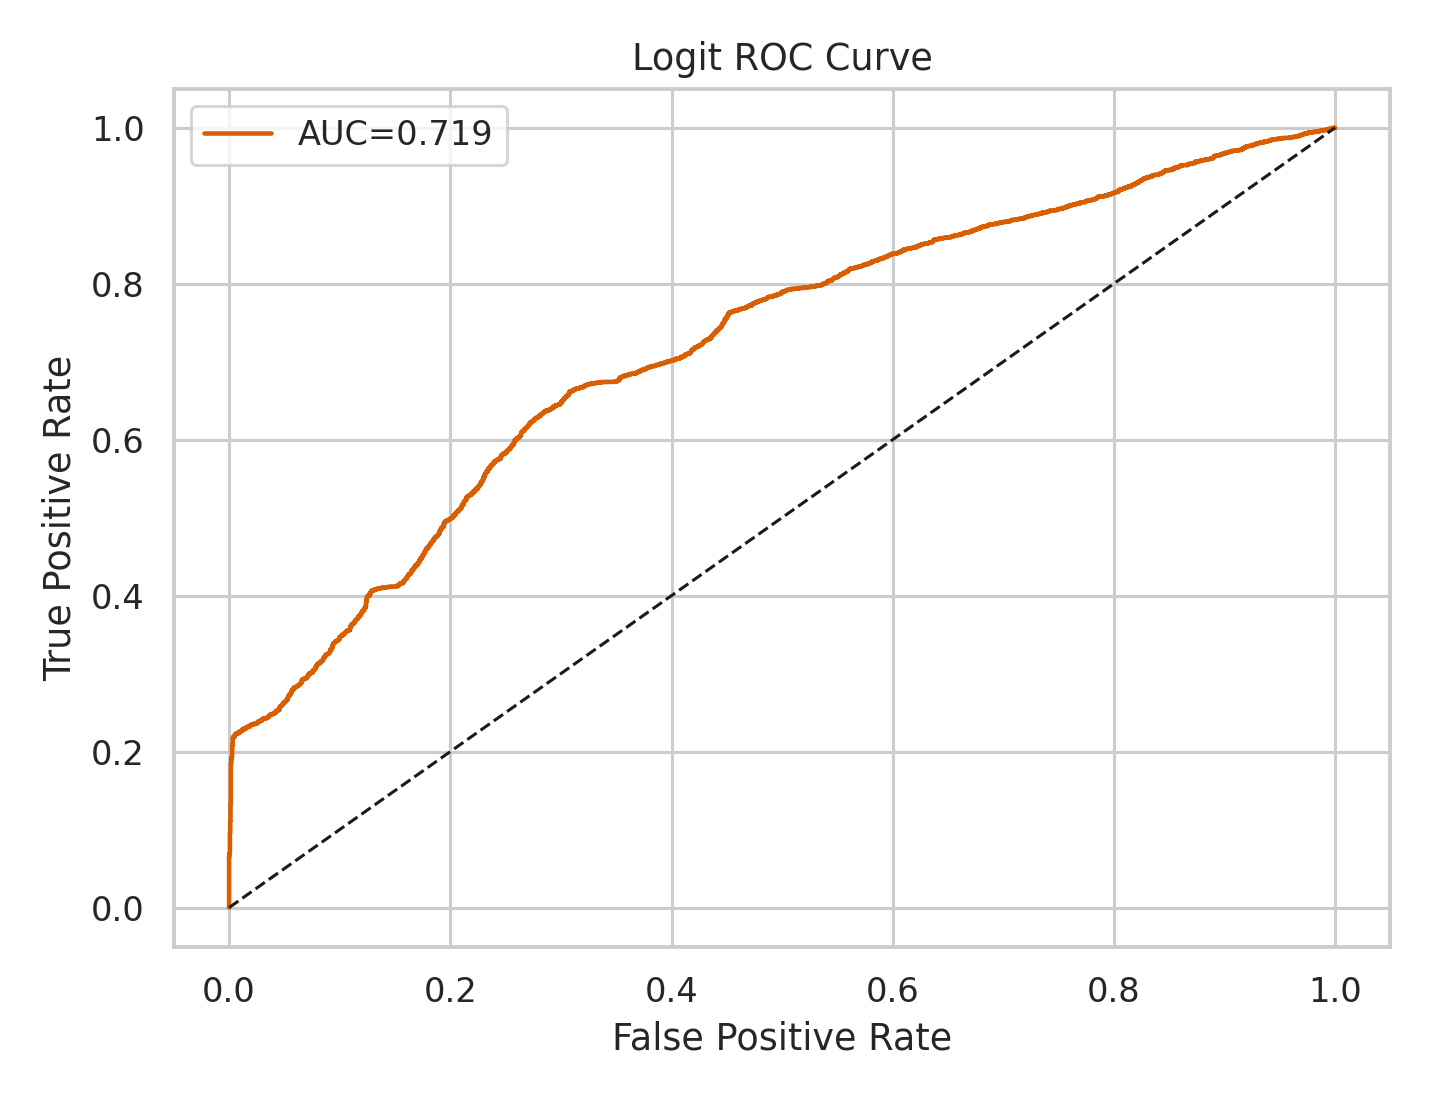

In [ ]:
# Embedded figure: logit_roc_curve.png


## Cox

### Purpose
Model recovery hazard.

### Why it remains useful
Cox still matters as an explanatory survival model, but it is no longer the best candidate for cross-event transport.

### Current reading
The project keeps a useful explanatory Cox signal, but Cox has not emerged as the most stable transport model once the event set becomes more heterogeneous.

Reference figure:

<img src="project/modeling_report/figures/cox/cox_hazard_ratio.png" width="820">

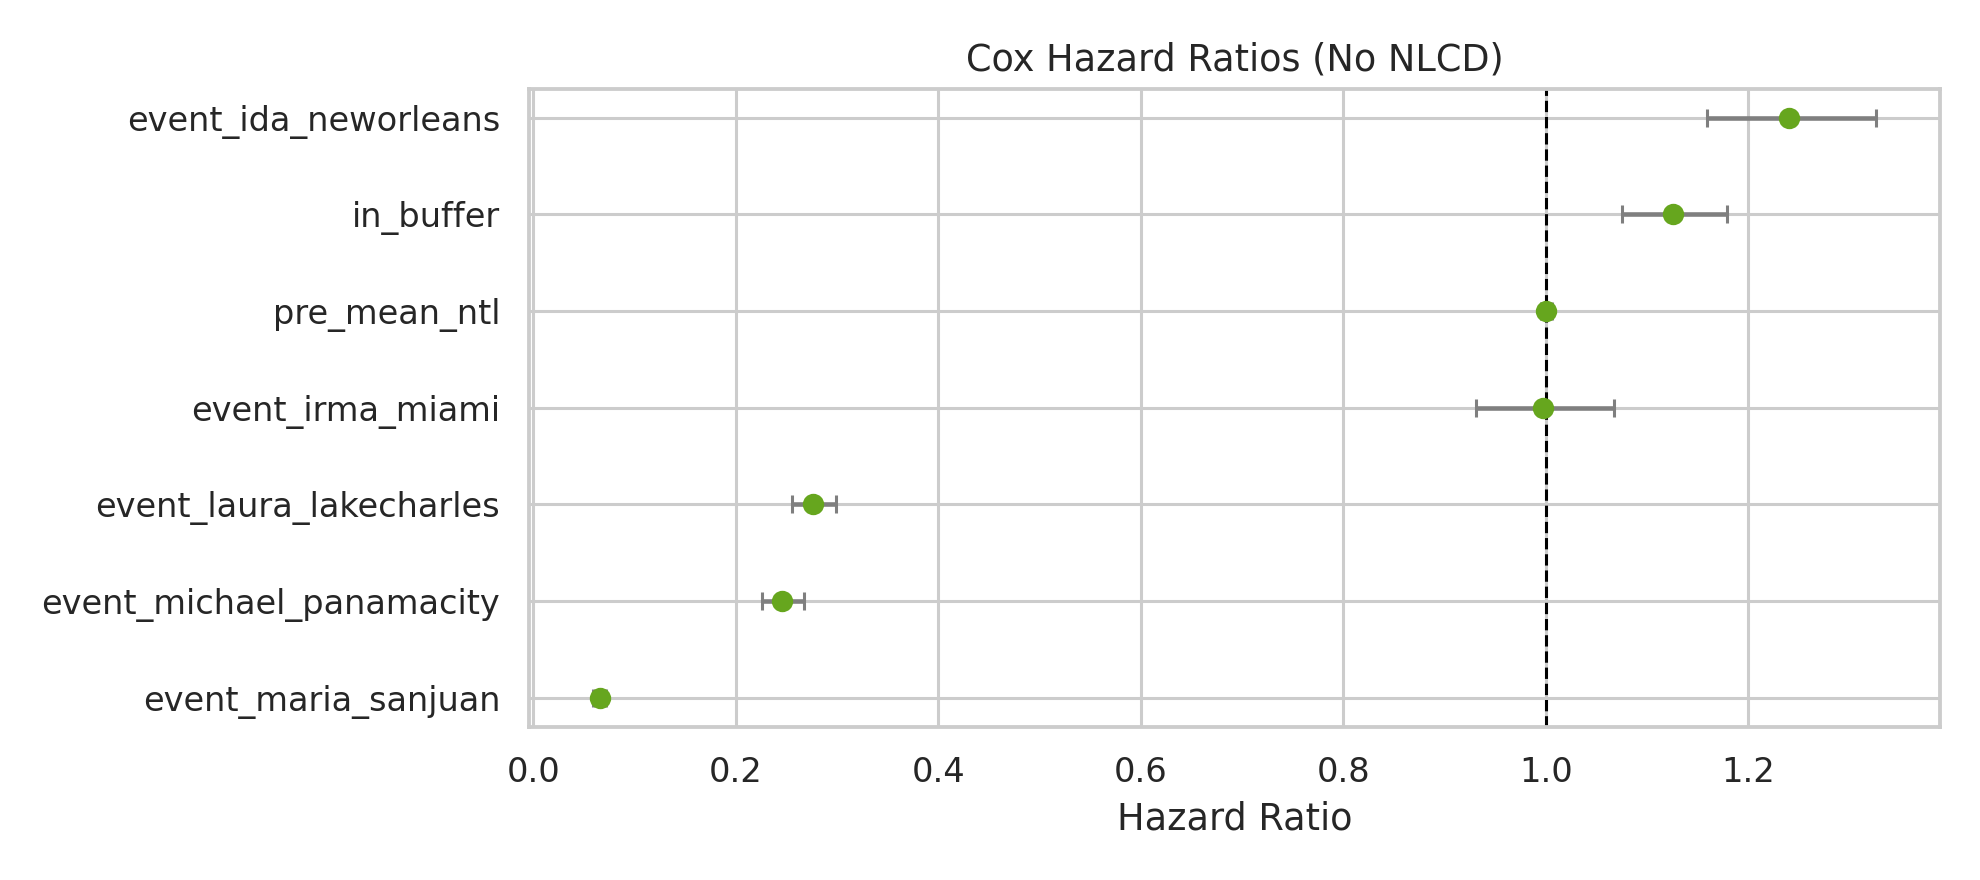

In [ ]:
# Embedded figure: cox_hazard_ratio.png


## AFT

### Purpose
Predict recovery timing using a more flexible survival formulation.

### Why it matters
AFT is often more practical than Cox for transport evaluation because it can be less sensitive to some of the proportional-hazard assumptions.

### Current reading
Even with that advantage, recovery transport is still the weakest part of the project. That is why we do not interpret the Stage 9/10 repair as a full success.

## Quality-matched models

### Purpose
Test whether the buffer effect survives stricter local comparisons.

### Why this matters
This line is the best defense against the criticism that buffer and non-buffer pixels are structurally incomparable.

### Current reading
The direction of the buffer effect remains present, but the signal becomes weaker after event expansion. This is still valuable because it shows that the explanatory claim has not disappeared, even though it is less concentrated than in the six-event baseline.

Reference figure:

<img src="project/modeling_report/figures/exploration_v2/quality_matched_compare_v1.png" width="820">

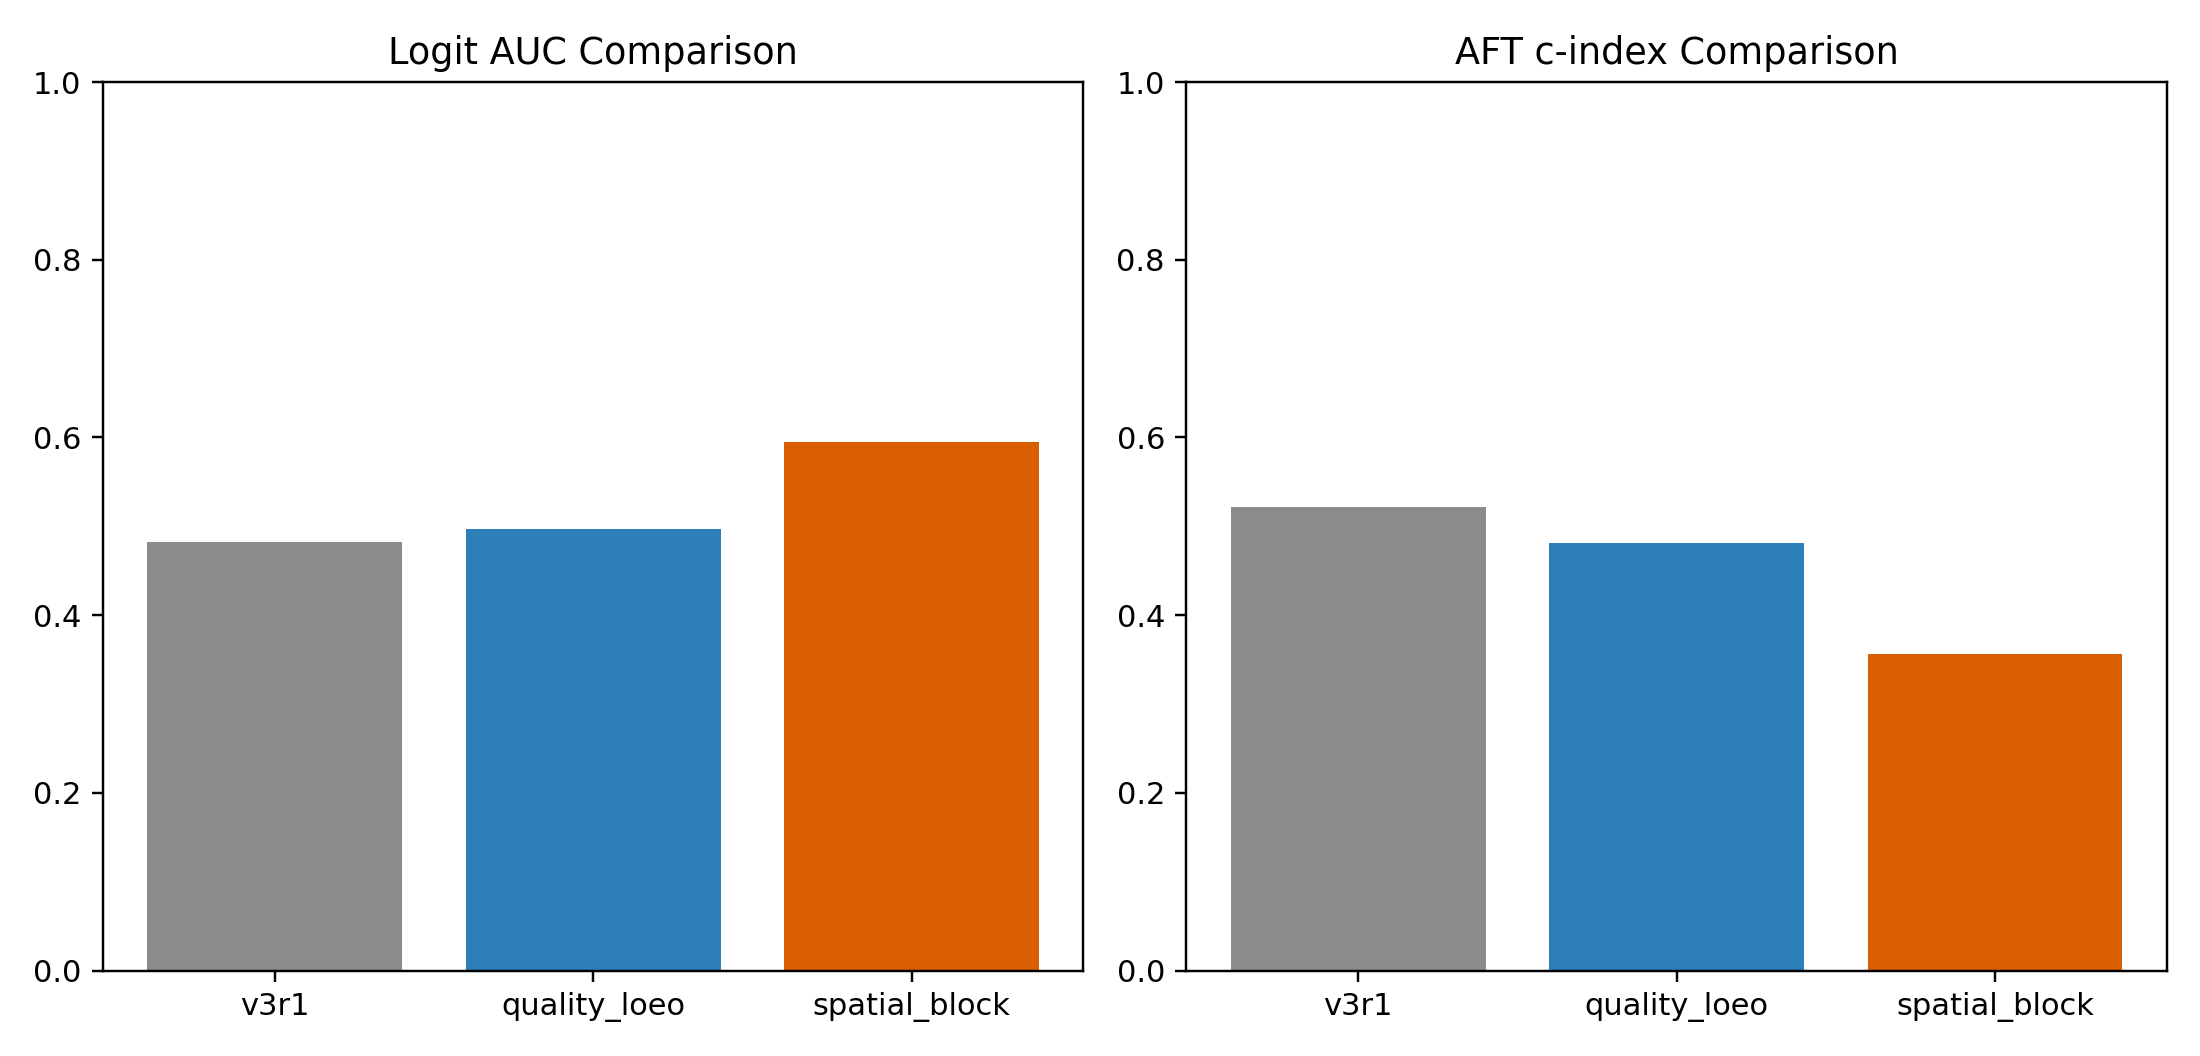

In [ ]:
# Embedded figure: quality_matched_compare_v1.png


## Current Interpretation

### If the goal is explanation
The project is already in a good state.

The strongest explanatory line is:

- `strict-v2`
- especially `MixedLM`
- supported by matched Logit

This line consistently supports the interpretation that buffer areas are more resilient than comparable non-buffer areas.

### If the goal is cross-event prediction
The project is only partially successful.

The strongest current statement is:

- the 6-event setup was learnable
- direct expansion to 10 events exposed real generalization failure
- repairing international covariates helped damage ranking
- recovery transport remains unresolved

## Event Readiness and Event Selection

One outcome of the latest repair stage is that we can now score events by readiness instead of treating all events as equally valid mainline training inputs.

Current readiness-based recommendation:

### Mainline candidates

- `ian_charlotteharbor`
- `earthquake_sanjuan`
- `ida_neworleans`
- `irma_miami`
- `laura_lakecharles`

### Sensitivity only

- `ian_fortmyers`

### Repair first

- `dorian_freeport`
- `earthquake_hatay`
- `maria_sanjuan`
- `michael_panamacity`

This is important because the project should no longer assume:

> more events always improve the main model.

That assumption is now empirically false.

Reference figure:

<img src="project/modeling_report/figures/intl_stage_repair_v1/event_readiness_score_v1.png" width="900">

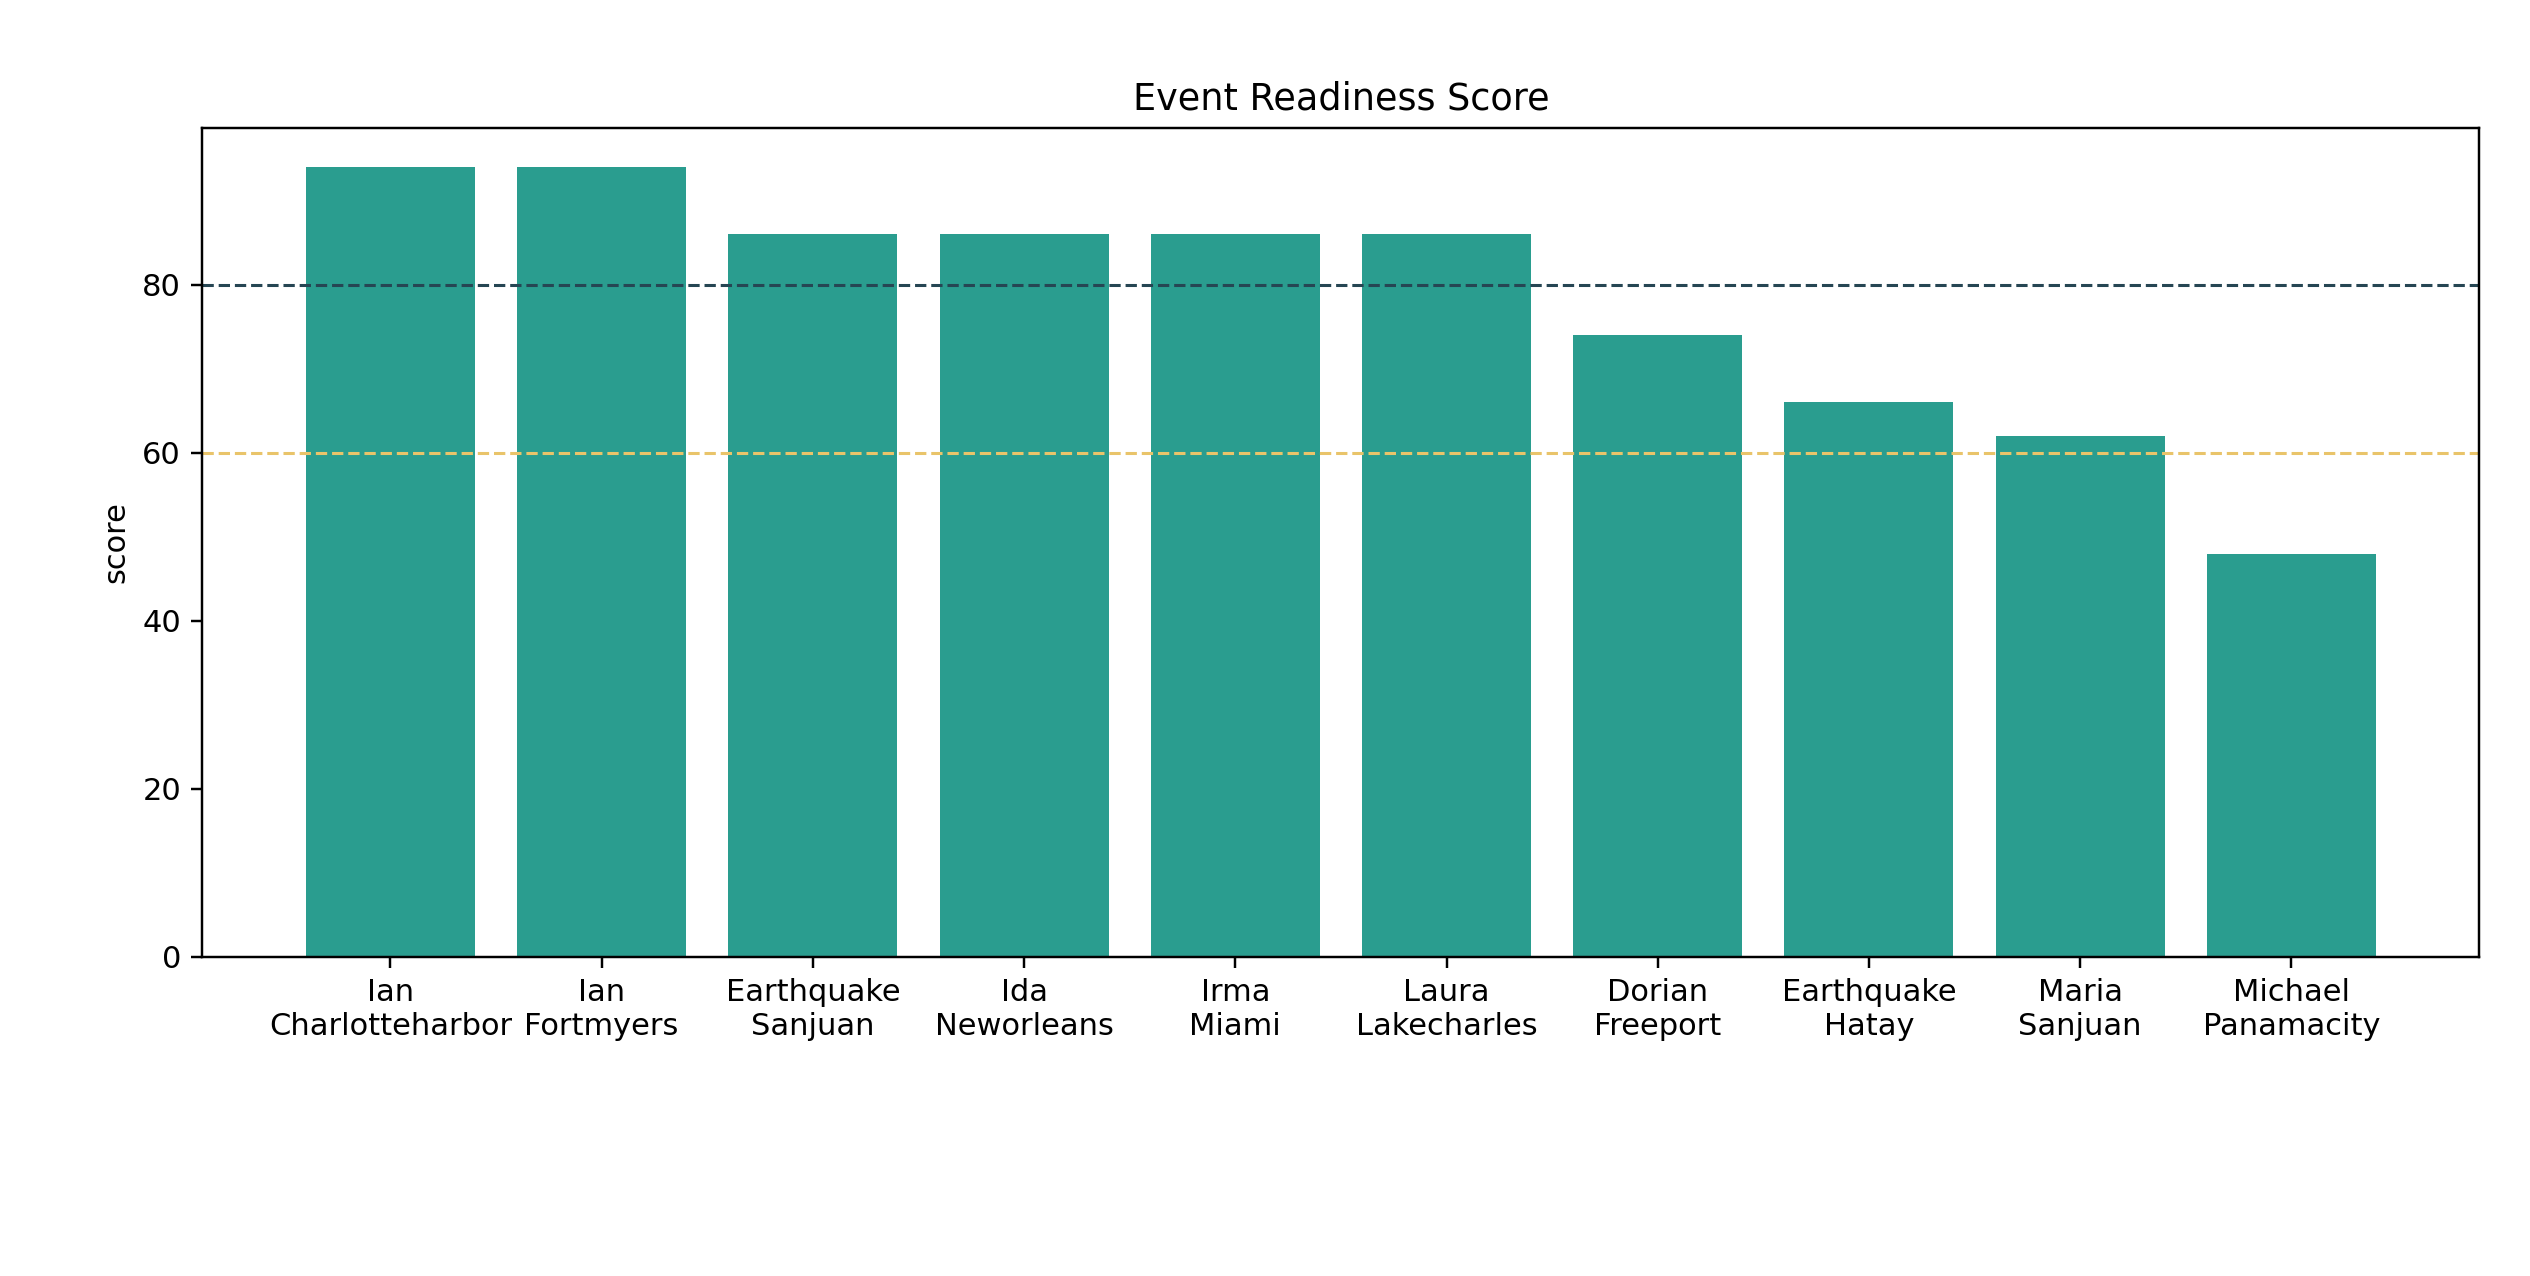

In [ ]:
# Embedded figure: event_readiness_score_v1.png


## What We Expect Next

The next phase should not blindly add more events. The better sequence is:

1. repair weak international covariates more completely
2. keep the transport line lean and stable
3. separate explanatory models from transport models more clearly
4. use event-readiness rules before moving new events into the main training set

Concretely, the current expected next actions are:

- strengthen international population and urbanization context
- continue using repaired transport specifications for difficult events
- keep `MixedLM` as the main explanatory model
- treat event expansion as conditional rather than automatic

## Main Takeaway

The project already has a stable explanatory framework. The main unresolved issue is cross-event transport after event expansion. Adding more events was still useful, because it revealed real heterogeneity that the old models were hiding. But it also showed that event diversity must be matched by:

- better covariates
- stricter event-entry rules
- and a clearer separation between explanation and transport

That is the current technical state of the project.